<a href="https://colab.research.google.com/github/coezbek/uts-94691-Deep-Learning-2026/blob/main/Assignment1_PartB_Instruction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neural Networks with PyTorch

In this assignment, we are going to train a Neural Networks on the Japanese MNIST dataset. It is composed of 70000 images of handwritten Hiragana characters. The target variables has 10 different classes.

Each image is of dimension 28 by 28. But we will flatten them to form a dataset composed of vectors of dimension (784, 1). The training process will be similar as for a structured dataset.

<img src='https://drive.google.com/uc?id=16TqEl9ESfXYbUpVafXD6h5UpJYGKfMxE' width="500" height="200">

Your goal is to run at least 3 experiments and get a model that can achieve 80% accuracy with not much overfitting on this dataset.

Some of the code have already been defined for you. You need only to add your code in the sections specified (marked with **TODO**). Some assert statements have been added to verify the expected outputs are correct. If it does throw an error, this means your implementation is behaving as expected.

Note: You can only use fully-connected and dropout layers for this assignment. You can not convolution layers for instance

# 1. Import Required Packages & Device Selection

[1.1] We are going to use numpy, matplotlib and google.colab packages

In [ ]:
from google.colab import drive
import numpy as np
import torch
import matplotlib.pyplot as plt
%pip install japanize-matplotlib

[1.2] We are going to select CUDA as device of choice

In [2]:
device = "cuda" if torch.cuda.is_available() else 'cpu'
device

'cuda'

[1.3] Set display/presentation options so that printing 28x28 images don't break lines.


In [3]:
torch.set_printoptions(linewidth=160)
np.set_printoptions(edgeitems=30, linewidth=160, 
    formatter=dict(float=lambda x: "%.3g" % x))

# 2. Download Dataset

We will store the dataset into your personal Google Drive.


[2.1] Mount Google Drive

In [4]:
drive.mount('/content/gdrive')

Mounted at /content/gdrive


[2.2] Create a folder called `DL_ASG_1` on your Google Drive at the root level

In [5]:
! mkdir -p /content/gdrive/MyDrive/DL_ASG_1

[2.3] Navigate to this folder

In [6]:
%cd '/content/gdrive/MyDrive/DL_ASG_1'

/content/gdrive/MyDrive/DL_ASG_1


[2.4] Show the list of item on the folder

In [7]:
!ls

kmnist-test-imgs.npz	kmnist-train-imgs.npz
kmnist-test-labels.npz	kmnist-train-labels.npz


[2.4] Dowload the dataset files to your Google Drive if required

In [8]:

# !curl -OJ --location-trusted --max-redirs 10 "https://drive.google.com/uc?export=download&id=10l2JdpT4_D_Gw0eiJ_X_iaYwC6_FYFom" 
!wget --trust-server-names --content-disposition --no-clobber "https://drive.google.com/uc?export=download&id=10l2JdpT4_D_Gw0eiJ_X_iaYwC6_FYFom"
!wget --trust-server-names --content-disposition --no-clobber "https://drive.google.com/uc?export=download&id=1PULvgUZZ6u7-2GTd0yaNPpwiU0ED_fD0"
!wget --trust-server-names --content-disposition --no-clobber "https://drive.google.com/uc?export=download&id=1gkS2LnoY5tdAuvaZNJ6kn6bsMp5uzD1B"
!wget --trust-server-names --content-disposition --no-clobber "https://drive.google.com/uc?export=download&id=1ovEOFfs-vZgYYFqXYnknAsn-DRWOgoU6"


--2026-02-27 03:14:26--  https://drive.google.com/uc?export=download&id=10l2JdpT4_D_Gw0eiJ_X_iaYwC6_FYFom
Resolving drive.google.com (drive.google.com)... 74.125.130.113, 74.125.130.102, 74.125.130.101, ...
Connecting to drive.google.com (drive.google.com)|74.125.130.113|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=10l2JdpT4_D_Gw0eiJ_X_iaYwC6_FYFom&export=download [following]
--2026-02-27 03:14:26--  https://drive.usercontent.google.com/download?id=10l2JdpT4_D_Gw0eiJ_X_iaYwC6_FYFom&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 74.125.200.132, 2404:6800:4003:c06::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|74.125.200.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
--2026-02-27 03:14:30--  https://drive.google.com/uc?export=download&id=1PULvgUZZ6u7-2GTd0yaNPpwiU0ED_fD0
Resolving drive.google.com (drive.goo

[2.5] List the content of the folder and confirm files have been dowloaded properly

In [9]:
! ls

kmnist-test-imgs.npz	kmnist-train-imgs.npz
kmnist-test-labels.npz	kmnist-train-labels.npz


# 3. Load Data

[3.1] Import the required modules from PyTorch

In [10]:
# I prefer to keep the code readable and directly enter torch.nn...

[3.2] **TODO** Create 2 variables called `img_height` and `img_width` that will both take the value 28

In [11]:
# TODO (Students need to fill this section)
img_height = 28
img_width = 28

[3.3] Create a function that loads a .npz file using numpy and return the content of the `arr_0` key

In [12]:
def load(f):
    return np.load(f)['arr_0']

[3.4] **TODO** Load the 4 files saved on your Google Drive into their respective variables: x_train, y_train, x_test and y_test

In [13]:
x_train = load('kmnist-train-imgs.npz')
x_test  = load('kmnist-test-imgs.npz')
y_train = load('kmnist-train-labels.npz')
y_test  = load('kmnist-test-labels.npz')

Quickly check if the data is as expected

In [14]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)
print(x_train[0])
print(f"Label: {y_train[0]}")


(60000, 28, 28)
(10000, 28, 28)
(60000,)
(10000,)
[[  0   0   0   0   0   0   0   0  10   7 233  86   0   0  32  99   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0  54 255  84   0   0   7 151  19   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0 152 251  14   0   0  25 155  98   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0 129 248 188   0   0   0  80 250 191   1  78  51   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0  87 217  62   0   0   0  66 255 254 225 234 160   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   2   0   0   0   4  93 247 244 184  95 132   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0  74 130 136 213 112 131   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 147  78  54 188 120  83   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0 

[3.5] **TODO** Using matplotlib display the first image from the train set and its target value

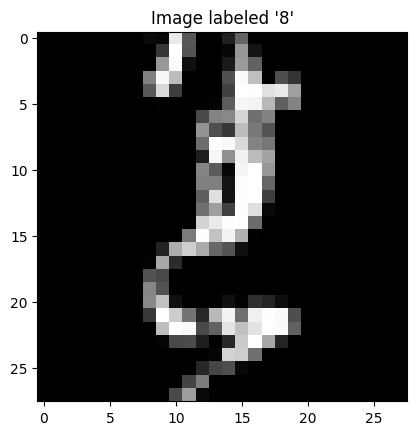

In [15]:
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Image labeled '{y_train[0]}'")
plt.show()

# 4. Prepare Data

[4.1] **TODO** Reshape the images from the training and testing set to have the channel dimension last. The dimensions should be: (row_number, height, width, channel)

In [16]:
x_train = torch.tensor(x_train).reshape(x_train.shape[0], -1)
x_test = torch.tensor(x_test).reshape(x_test.shape[0], -1)
print(x_train.shape)

torch.Size([60000, 784])


[4.2] **TODO** Cast `x_train` and `x_test` into `float32` decimals

In [17]:
x_train = x_train.to(dtype=torch.float32)
x_test = x_test.to(dtype=torch.float32)

[4.3] **TODO** Standardise the images of the training and testing sets. Originally each image contains pixels with value ranging from 0 to 255. after standardisation, the new value range should be from 0 to 1.

In [18]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [19]:
# Make sure we didn't mess up
assert ((x_train >= 0.0) & (x_train <= 1.0)).all()
assert ((x_test >= 0.0) & (x_test <= 1.0)).all()

[4.4] **TODO** Create a variable called `num_classes` that will take the value 10 which corresponds to the number of classes for the target variable

In [20]:
# TODO (Students need to fill this section)
num_classes = len(np.unique(y_train))

print(f"How many different labels are in y_train? => {np.unique(y_train)} = i.e. {num_classes} different labels")


How many different labels are in y_train? => [0 1 2 3 4 5 6 7 8 9] = i.e. 10 different labels


[4.5] **TODO** Convert the target variable for the training and testing sets to a binary class matrix of dimension (rows, num_classes).

For example:
- class 0 will become [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
- class 1 will become [0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
- class 5 will become [0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
- class 9 will become [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]

In [21]:
def to_binary_class_matrix(x):
  x = torch.tensor(x, dtype=torch.long) # Must convert, otherwise it seems that torch believes we want to apply a binary mask
  _x = torch.zeros(x.shape[0], num_classes)
  _x[torch.arange(x.shape[0]), x] = 1 # Reading more on it, torch.nn.functional.one_hot might have been the best choice here
  return _x

y_train_cm = to_binary_class_matrix(y_train)
y_test_cm = to_binary_class_matrix(y_test) 
print(y_train_cm[:5])

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]])


# 5. Define Neural Networks Architecure

[5.1] Set the seed in PyTorch for reproducing results



In [22]:
torch.manual_seed(42)

[5.2] **TODO** Define the architecture of your Neural Networks and save it into a variable called `model`

In [23]:
input_size = 28*28

simple_model = torch.nn.Sequential(
  torch.nn.Linear(input_size, 512),
  torch.nn.ReLU(),
  torch.nn.Linear(512, num_classes)
).to(device)

[5.2] **TODO** Print the summary of your model

In [24]:
simple_model

Sequential(
  (0): Linear(in_features=784, out_features=512, bias=True)
  (1): ReLU()
  (2): Linear(in_features=512, out_features=10, bias=True)
)

# 6. Train Neural Networks

[6.1] **TODO** Create 2 variables called `batch_size` and `epochs` that will  respectively take the values 128 and 500

In [25]:
batch_size = 1024
epochs = 500

[6.2] **TODO** Compile your model with the appropriate loss function, the optimiser of your choice and the accuracy metric

In [26]:
loss_function = torch.nn.CrossEntropyLoss() # Categorical cross entropy loss for multi-class categorization task
optim = torch.optim.AdamW(params=simple_model.parameters(), lr=0.005, weight_decay=1e-3) # Use weighted Adam optimizer

train_dataset = torch.utils.data.TensorDataset(x_train, y_train_cm)
test_dataset = torch.utils.data.TensorDataset(x_test, y_test_cm)

dataloader_train = torch.utils.data.DataLoader(train_dataset, batch_size = batch_size, shuffle=True)
dataloader_test = torch.utils.data.DataLoader(test_dataset, batch_size = batch_size, shuffle=True)

[6.2b] Define plotting function for plotting losses and accuracy

In [27]:
from IPython.display import clear_output

def do_loss_plot(training_history):
    """
    Pass an array of hashes representing the training runs to generate a plot of loss+accuracy. 
    Each hash is a single training run and needs epoch, n_epochs, training_loss, testing_loss and accuracy.

    Acknowledgement: I needed help from Gemini to get the simultaneous axis right.
    """
    
    clear_output(wait=True)
    
    _, ax1 = plt.subplots(figsize=(10, 6))
    
    n_epochs = training_history[0]['n_epochs']
    i_epochs = max([d["epoch"] for d in training_history])
    epochs_range =[d["epoch"]+1 for d in training_history]
    
    # Left axis for loss
    color = 'tab:red'
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss', color=color, fontsize=12)
    l1 = ax1.plot(epochs_range, [d["training_loss"] for d in training_history], label='Train Loss', color=color, linestyle='-', alpha=0.7)
    l2 = ax1.plot(epochs_range, [d["testing_loss"] for d in training_history], label='Test Loss', color=color, linestyle='--', linewidth=2)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, max([d["testing_loss"] for d in training_history])) # Left axis from 0.0 to max
    
    # Right axis for accuracy
    ax2 = ax1.twinx()  
    color = 'tab:blue'
    ax2.set_ylabel('Accuracy', color=color, fontsize=12)
    l3 = ax2.plot(epochs_range, [d["accuracy"] for d in training_history], label='Test Accuracy', color=color, linewidth=3)
    ax2.tick_params(axis='y', labelcolor=color)
    ax2.set_ylim(0, 1.0) # 0-100% scale
    
    lines = l1 + l2 + l3 # Combine legends from both axes
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='center right')
    
    plt.title(f"Training Progress - Epoch {i_epochs+1:d}/{n_epochs}")
    plt.tight_layout()
    plt.show()
    

[6.3] **TODO** Train your model
using the number of epochs defined. Calculate the total loss and save it to a variable called total_loss.

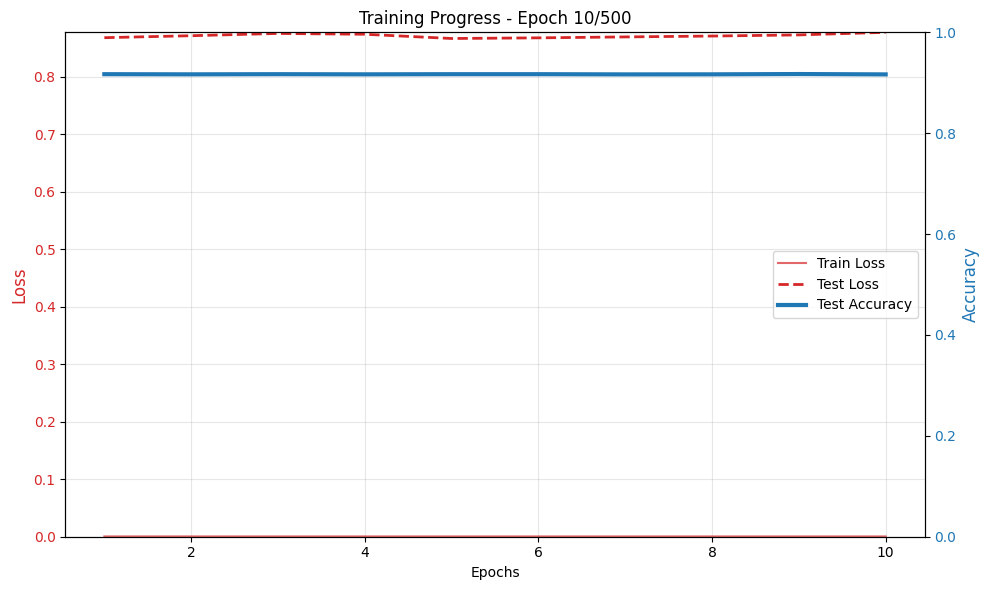

Epoch   1: 'Training Loss' 0.0005 - Testing Loss: 0.8682 = 91.7% accuracy
Epoch   2: 'Training Loss' 0.0005 - Testing Loss: 0.8716 = 91.7% accuracy
Epoch   3: 'Training Loss' 0.0005 - Testing Loss: 0.8756 = 91.7% accuracy
Epoch   4: 'Training Loss' 0.0005 - Testing Loss: 0.8742 = 91.7% accuracy
Epoch   5: 'Training Loss' 0.0005 - Testing Loss: 0.8668 = 91.7% accuracy
Epoch   6: 'Training Loss' 0.0005 - Testing Loss: 0.8679 = 91.7% accuracy
Epoch   7: 'Training Loss' 0.0005 - Testing Loss: 0.8695 = 91.7% accuracy
Epoch   8: 'Training Loss' 0.0005 - Testing Loss: 0.8710 = 91.7% accuracy
Epoch   9: 'Training Loss' 0.0005 - Testing Loss: 0.8730 = 91.7% accuracy
Epoch  10: 'Training Loss' 0.0005 - Testing Loss: 0.8775 = 91.7% accuracy


KeyboardInterrupt: 

In [50]:
def train_one_epoch(dataloader, model, data_augmentation, optimizer, loss_function, device):
    total_loss = 0

    # Set the model to training model
    model.train()
    for data, target in dataloader:

        # Move tensors to the same device as the model
        data = data.to(device)
        target = target.to(device)

        # CÖ: I added a data_augmentation function to scale/rotate/shift the images to increase the available data for the model
        if data_augmentation:
            data = data_augmentation(data)

        # Reset the gradients
        optimizer.zero_grad()

        # Forward Propagation to get predicted outcome
        outputs = model(data)

        # Compute the loss
        loss = loss_function(outputs, target)

        # Compute gradients
        loss.backward()

        # Update the weights
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

def test_one_epoch(dataloader, model, loss_func, device):
    
    testing_loss = 0.0
    correct_predictions = 0

    targets = []
    predictions = []
    images = [] 

    # Set the model to evaluation mode
    model.eval()
    with torch.no_grad():
        for data, target in dataloader:

            # Move tensors to the same device as the model
            data = data.to(device)
            target = target.to(device)

            # Forward Propagation to get predicted outcome
            outputs = model(data)

            # Store for confusion matrix
            targets.extend(target.argmax(dim=1).cpu().tolist())
            predictions.extend(outputs.argmax(dim=1).cpu().tolist())
            images.extend(data.cpu().numpy())

            # Compute the loss
            loss = loss_func(outputs, target)

            # Debug Prints:
            # print(outputs[0])
            # print(target[0])
            # print(outputs.argmax(dim=1))
            # print(target.argmax(dim=1))

            # Check if we predicted correctly
            correct_predictions += (outputs.argmax(dim=1) == target.argmax(dim=1)).type(torch.float32).sum().item()

            testing_loss += loss.item()

    return testing_loss / len(dataloader), correct_predictions / len(dataloader.dataset), targets, predictions, images

def run_experiment(model, aug_layer, optim):
    progress_info = []

    for i in range(epochs):
        total_loss = train_one_epoch(dataloader_train, model, aug_layer, optim, loss_function, device)
        testing_loss, accuracy, _, _, _= test_one_epoch(dataloader_test, model, loss_function, device)
        
        progress = {
            'training_loss': total_loss,
            'testing_loss': testing_loss,
            'accuracy': accuracy,
            'epoch': i,
            'n_epochs': epochs,
        }

        yield progress

        progress_info.append(progress)

        # Print every 10th epoch
        if (i+1) % 10 == 0:
            do_loss_plot(progress_info)
            for i in torch.linspace(0, len(progress_info) - 1, steps = min(len(progress_info), 10), dtype=torch.int):
                print(f"Epoch {i+1:>3d}: 'Training Loss' {progress_info[i]['training_loss']:.4f} - Testing Loss: {progress_info[i]['testing_loss']:.4f} = {progress_info[i]['accuracy'] * 100:.1f}% accuracy")


# First, we do not use data augmentation, just the simple model from above
progress_info = []
for progress in run_experiment(simple_model, None, optim):
    progress_info.append(progress)



[6.4] **DONE** Test your model.  Initiate the model.eval() along with torch.no_grad() to turn off the gradients.


In [52]:
# Also see above [6.3], after each training epoch
testing_loss, accuracy, latest_targets, latest_predictions, latest_images = test_one_epoch(dataloader_test, simple_model, loss_function, device)
print(f"Epoch {epochs:>3d}: Testing Loss: {testing_loss:.4f} = {accuracy * 100:.1f}% accuracy")

Epoch 500: Testing Loss: 0.8824 = 91.7% accuracy


I ran the following experiments:

- With Affine Rotation, Scale, Translate 15 degrees, 0.1 offset, 0.9-1.1 scale, 300 epoch, batch size 4096, 0.1 dropout in final layer, 784 x 64 x 10: Epoch 300: 'Training Loss' 0.1095 - Testing Loss: 0.2155 = 94.2% accuracy
- With Affine Rotation, Scale, Translate 10 degrees, 0.05 offset, 0.9-1.1 scale, 300 epoch, batch size 4096, 0.1 dropout in final layer, 784 x 64 x 64 x 10: Epoch 300: 'Training Loss' 0.0366 - Testing Loss: 0.2177 = 95.1% accuracy
- Adding one more 64 layer: : 'Training Loss' 0.0312 - Testing Loss: 0.2598 = 94.6% accuracy => more overfitting (?)
- Adding Color Jitter (but not starting from scratch): 'Training Loss' 0.0205 - Testing Loss: 0.2750 = 95.4% accuracy
- Increasing Color Jitter to 0.3/0.3: 'Training Loss' 0.0387 - Testing Loss: 0.2500 = 94.9% accuracy
- Even one 64 layer deeper and moved Dropout from the back to the front: Epoch 300: 'Training Loss' 0.0597 - Testing Loss: 0.1947 = 95.6% accuracy
- lr from 0.001 to 0.01: 'Training Loss' 0.1022 - Testing Loss: 0.2187 = 94.8% accuracy
- lr from 0.001 to 0.0005: 'Training Loss' 0.0913 - Testing Loss: 0.1935 = 95.2% accuracy => Learning was still on-going, so might need more epochs
- lr at 0.0005 - Affine Scaling down to 0.6-1.1 - batch_size = 8192 (from 4096): 'Training Loss' 0.1759 - Testing Loss: 0.2425 = 93.9% accuracy
- very deep architecture 5000 epochs: Epoch 5000: 'Training Loss' 0.0469 - Testing Loss: 0.1557 = 96.5% accuracy


# 7. Analyse Results

[7.1] **TODO** Display the performance of your model on the training and testing sets

In [46]:
# TODO (Students need to fill this section)
print()

[7.2] **TODO** Plot the learning curve of your model

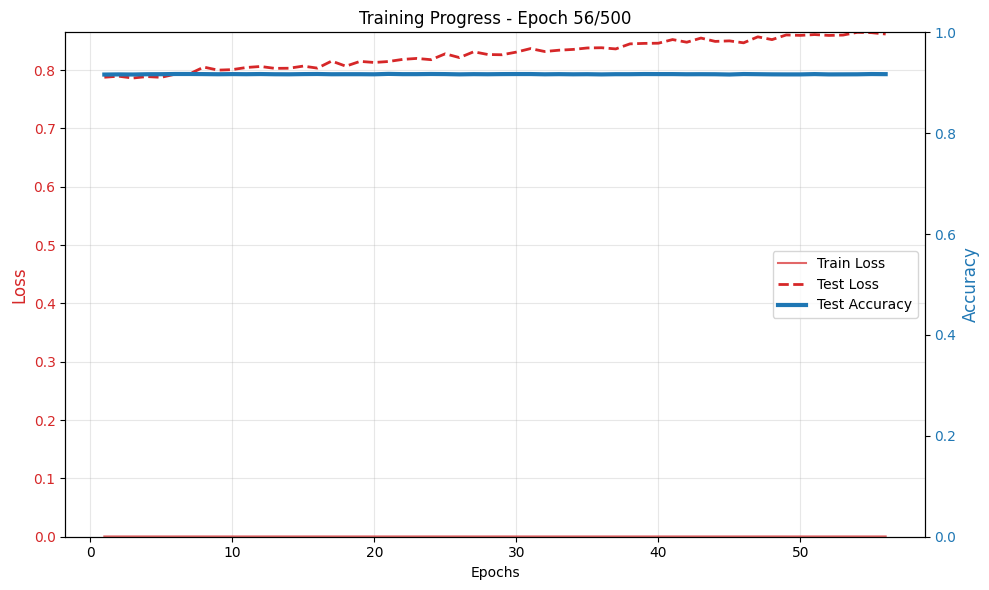

In [47]:
do_loss_plot(progress_info)

[7.3] **TODO** Display the confusion matrix on the testing set predictions

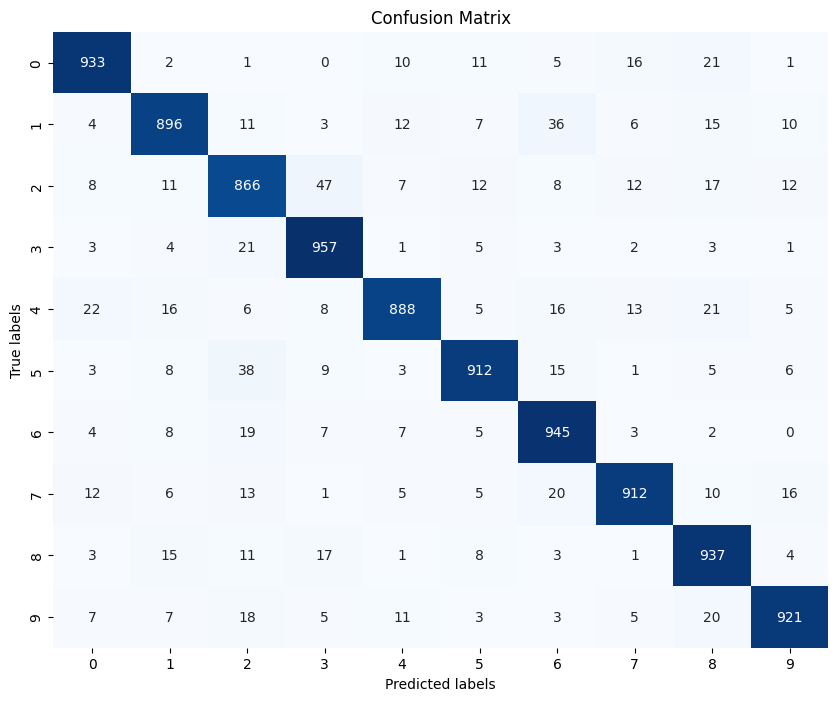

In [61]:
import matplotlib.pyplot as plt
import matplotlib
import seaborn #.heatmap
import sklearn.metrics #.confusion_matrix

def plot_confusion_matrix(true_labels, predicted_labels):
  # Adapted from exercise 2 of lesson 2 of UTS Deep Learning Autumn 2026

  conf_matrix = sklearn.metrics.confusion_matrix(true_labels, predicted_labels)

  # Plotting the confusion matrix
  plt.figure(figsize=(10, 8))
  seaborn.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
  plt.xlabel('Predicted labels')
  plt.ylabel('True labels')
  plt.title('Confusion Matrix')
  plt.show()

plot_confusion_matrix(latest_targets, latest_predictions)

[7.4] Let's examine one misprediction example in the cell with the most mispredictions

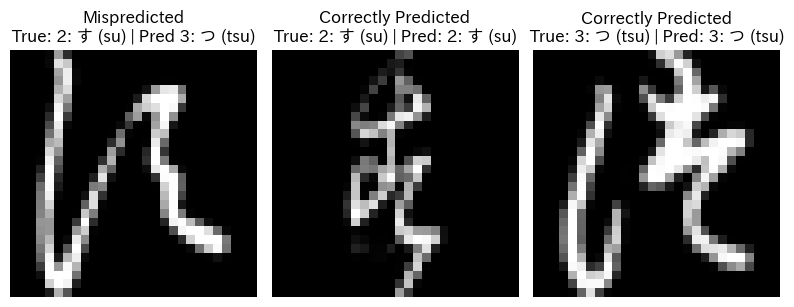

In [86]:
# This code was created with support from Gemini Pro 3.1 to get Japanese character printing right and matplotlib parameters

class_map = [
  "0: お (o)",
  "1: き (ki)",
  "2: す (su)",
  "3: つ (tsu)",
  "4: な (na)",
  "5: は (ha)",
  "6: ま (ma)",
  "7: や (ya)",
  "8: れ (re)",
  "9: を (wo)",
]
import japanize_matplotlib


# Convert lists to numpy arrays so we can easily filter them
targets_arr = np.array(latest_targets)
preds_arr = np.array(latest_predictions)
images_arr = np.array(latest_images)

conf_matrix = sklearn.metrics.confusion_matrix(latest_targets, latest_predictions)
np.fill_diagonal(conf_matrix, 0)
max_idx = np.argmax(conf_matrix)
true_label, pred_label = np.unravel_index(max_idx, conf_matrix.shape)

# the following example assumes true label is 2 and predicted label was 4

# 1. Find indices where true label is 2 but it was predicted as 4
mispredicted_mask = (targets_arr == true_label) & (preds_arr == pred_label)
mispredicted_indices = np.where(mispredicted_mask)[0]

# 2. Find indices where true label is 2 and it was correctly predicted as 2
correct_2_mask = (targets_arr == true_label) & (preds_arr == true_label)
correct_2_indices = np.where(correct_2_mask)[0]

# Find indices where true label is 4 and it was correctly predicted as 4
correct_4_mask = (targets_arr == pred_label) & (preds_arr == pred_label)
correct_4_indices = np.where(correct_4_mask)[0]

if len(mispredicted_indices) > 0 and len(correct_2_indices) > 0 and len(correct_4_indices) > 0:
    
    idx_mispredicted = np.random.choice(mispredicted_indices)
    idx_correct = np.random.choice(correct_2_indices)
    idx_correct4 = np.random.choice(correct_4_indices)

    # Extract the images and reshape them from (784,) back to (28, 28)
    img_mispredicted = images_arr[idx_mispredicted].reshape(28, 28)
    img_correct = images_arr[idx_correct].reshape(28, 28)
    img_correct4 = images_arr[idx_correct4].reshape(28, 28)

    # Plot them side by side
    fig, axes = plt.subplots(1, 3, figsize=(8, 4))

    axes[0].imshow(img_mispredicted, cmap='gray')
    axes[0].set_title(f"Mispredicted\nTrue: {class_map[true_label]} | Pred {class_map[pred_label]}")
    axes[0].axis('off')

    axes[1].imshow(img_correct, cmap='gray')
    axes[1].set_title(f"Correctly Predicted\nTrue: {class_map[true_label]} | Pred: {class_map[true_label]}")
    axes[1].axis('off')

    axes[2].imshow(img_correct4, cmap='gray')
    axes[2].set_title(f"Correctly Predicted\nTrue: {class_map[pred_label]} | Pred: {class_map[pred_label]}")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Could not find examples of a 2 mispredicted as a 4.")

# 8 Experimenting to improve the model

The initial simple model used above with layers of [512, 512, 10] neurons is quickly overfitting on the little amount of available data. This is clearly visible from the loss curve where the training loss quickly approaches 0.0, but the training loss isn't further decreasing after a local minimum early on, but increasing constantly.

It is thus appropriate to use methods to prevent overfitting such as:

- Using data augmentation to increase the data versatility which also prevents learning static patterns
- Using dropouts to reduce dependence on individual neurons for classification

## 8.1 Data Augmentation

For image data as our KMNIST samples, we have the option to use simple image transformations such as rotating, scaling, transposing the image as well as changing the gray scale colors. These augmentation prevent that the neural network just learns to focus on individual pixel combinations present in the images.



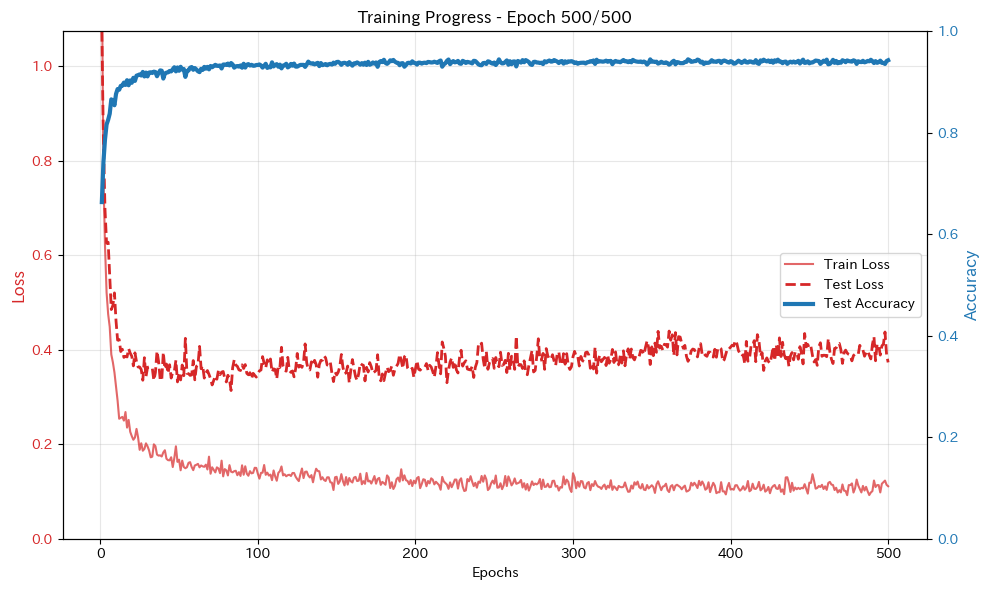

Epoch   1: 'Training Loss' 1.2120 - Testing Loss: 1.0740 = 66.3% accuracy
Epoch  56: 'Training Loss' 0.1606 - Testing Loss: 0.3494 = 92.3% accuracy
Epoch 111: 'Training Loss' 0.1318 - Testing Loss: 0.3582 = 93.4% accuracy
Epoch 167: 'Training Loss' 0.1218 - Testing Loss: 0.3669 = 93.4% accuracy
Epoch 222: 'Training Loss' 0.1193 - Testing Loss: 0.3741 = 93.5% accuracy
Epoch 278: 'Training Loss' 0.1179 - Testing Loss: 0.4232 = 93.8% accuracy
Epoch 333: 'Training Loss' 0.1191 - Testing Loss: 0.3660 = 94.1% accuracy
Epoch 389: 'Training Loss' 0.1184 - Testing Loss: 0.3845 = 94.0% accuracy
Epoch 444: 'Training Loss' 0.1052 - Testing Loss: 0.4066 = 93.7% accuracy
Epoch 500: 'Training Loss' 0.1111 - Testing Loss: 0.3733 = 94.3% accuracy


In [89]:
from torchvision import transforms

aug_layer = torch.nn.Sequential(
    torch.nn.Unflatten(1, (1, 28, 28)), # Need to shape to match the image dimensions again
    transforms.RandomRotation(degrees=10), # plus and minus 10 degrees
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.6, 1.1)), # scale and translate 
    transforms.ColorJitter(brightness=0.3, contrast=0.3), # increase/decrease brightness and contrast by 30%
    torch.nn.Flatten(1, -1) # go back to 28*28 tensors in the last dimension
).to(device)

model_augmented = torch.nn.Sequential(
  torch.nn.Linear(input_size, 512),
  torch.nn.ReLU(),
  torch.nn.Linear(512, num_classes)
).to(device)

optim = torch.optim.AdamW(params=model_augmented.parameters(), lr=0.005, weight_decay=1e-3) # Use weighted Adam optimizer

progress_info_augmented = []
for progress in run_experiment(model_augmented, aug_layer, optim):
    progress_info_augmented.append(progress)

## 8.2 Using Dropout

The wide gap between training and test accuracy indicates that the model is still overfitting on data. As a third experiment, I added a dropout of 0.2 (20%) to the first layer.

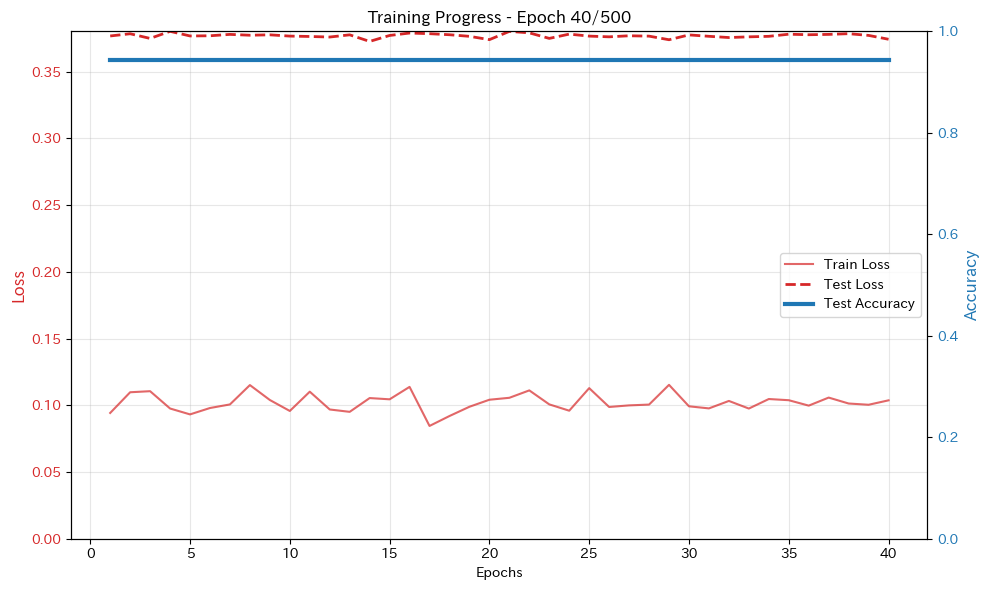

Epoch   1: 'Training Loss' 0.0942 - Testing Loss: 0.3767 = 94.3% accuracy
Epoch   5: 'Training Loss' 0.0932 - Testing Loss: 0.3767 = 94.3% accuracy
Epoch   9: 'Training Loss' 0.1039 - Testing Loss: 0.3776 = 94.3% accuracy
Epoch  14: 'Training Loss' 0.1054 - Testing Loss: 0.3726 = 94.3% accuracy
Epoch  18: 'Training Loss' 0.0919 - Testing Loss: 0.3776 = 94.3% accuracy
Epoch  22: 'Training Loss' 0.1111 - Testing Loss: 0.3791 = 94.3% accuracy
Epoch  27: 'Training Loss' 0.0999 - Testing Loss: 0.3769 = 94.3% accuracy
Epoch  31: 'Training Loss' 0.0977 - Testing Loss: 0.3765 = 94.3% accuracy
Epoch  35: 'Training Loss' 0.1038 - Testing Loss: 0.3780 = 94.3% accuracy
Epoch  40: 'Training Loss' 0.1037 - Testing Loss: 0.3742 = 94.3% accuracy


: 

: 

In [ ]:
model_dropout = torch.nn.Sequential(
  torch.nn.Linear(input_size, 512),
  torch.nn.ReLU(),
  torch.nn.Dropout(0.2),
  torch.nn.Linear(512, num_classes)
).to(device)

optim = torch.optim.AdamW(params=model_dropout.parameters(), lr=0.005, weight_decay=1e-3) # Use weighted Adam optimizer

progress_info_dropout = []
for progress in run_experiment(model_augmented, aug_layer, optim):
    progress_info_dropout.append(progress)


In [ ]:







model = torch.nn.Sequential(
  torch.nn.Linear(input_size, layer1_size),
  torch.nn.ReLU(),
  torch.nn.Dropout(0.2),
  # torch.nn.Dropout(0.5),
  torch.nn.Linear(layer1_size, layer2_size),
  torch.nn.ReLU(),
  torch.nn.Dropout(0.1),
  torch.nn.Linear(layer2_size, layer2_size),
  torch.nn.ReLU(),
  torch.nn.Linear(layer2_size, layer2_size),
  torch.nn.ReLU(),
  torch.nn.Linear(layer2_size, layer2_size),
  torch.nn.ReLU(),
  torch.nn.Linear(layer2_size, layer2_size),
  torch.nn.ReLU(),
  torch.nn.Linear(layer2_size, layer2_size),
  torch.nn.ReLU(),
  torch.nn.Linear(layer2_size, layer2_size),
  torch.nn.ReLU(),
  torch.nn.Linear(layer2_size, layer2_size),
  torch.nn.ReLU(),
  torch.nn.Linear(layer2_size, layer2_size),
  torch.nn.ReLU(),
  torch.nn.Linear(layer2_size, layer2_size),
  torch.nn.ReLU(),
  # torch.nn.Dropout(0.5),
  # torch.nn.Linear(layer2_size, layer2_size),
  # torch.nn.ReLU(),
  torch.nn.Linear(layer2_size, num_classes)  
).to(device)


# 9 Bibliography and Acknowledgement


- KMNIST 
https://arxiv.org/pdf/1812.01718

